In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Analysing Given Data

              CircleName      RegionName       DivisionName  \
0  Andhra Pradesh Circle  Kurnool Region  Hindupur Division   
1  Andhra Pradesh Circle  Kurnool Region  Hindupur Division   
2  Andhra Pradesh Circle  Kurnool Region  Hindupur Division   
3  Andhra Pradesh Circle  Kurnool Region  Hindupur Division   
4  Andhra Pradesh Circle  Kurnool Region  Hindupur Division   

            OfficeName  Pincode OfficeType  Delivery   District  \
0       Peddakotla B.O   515631         BO  Delivery  ANANTAPUR   
1       Pinnadhari B.O   515631         BO  Delivery  ANANTAPUR   
2  Yerraguntapalle B.O   515631         BO  Delivery  ANANTAPUR   
3  Obulareddipalli B.O   515581         BO  Delivery  ANANTAPUR   
4       Odulapalli B.O   515581         BO  Delivery  ANANTAPUR   

        StateName   Latitude  Longitude  
0  ANDHRA PRADESH    14.5689   77.85624  
1  ANDHRA PRADESH    14.5281  77.857014  
2  ANDHRA PRADESH  14.561111   77.85715  
3  ANDHRA PRADESH    14.2488    78.2588  
4  ANDHR

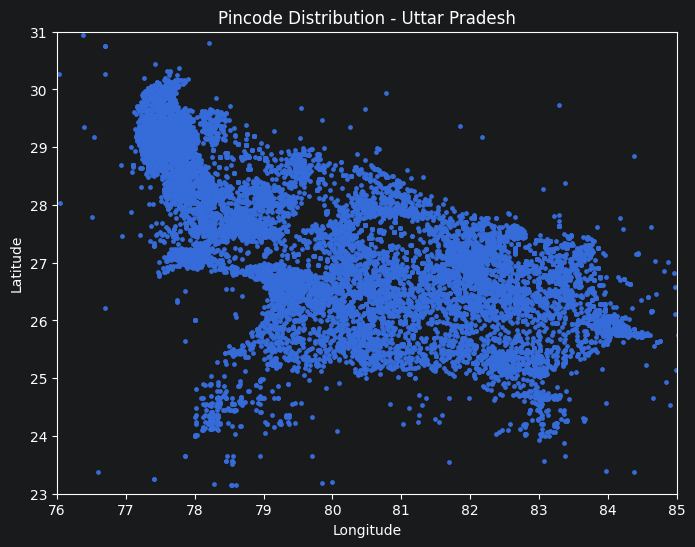

In [172]:
df = pd.read_csv("clustering_data.csv", low_memory=False)
print(df.head())

up_df = df[df['StateName'] == 'UTTAR PRADESH']
print(up_df['Latitude'].dtype) # Checking if numeric
# Changed to Numeric for plotting
up_df['Latitude'] = pd.to_numeric(up_df['Latitude'], errors='coerce')
up_df['Longitude'] = pd.to_numeric(up_df['Longitude'], errors='coerce')

plt.figure(figsize=(8,6))
plt.scatter(up_df['Longitude'], up_df['Latitude'], s=6)
plt.title("Pincode Distribution - Uttar Pradesh")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(76,85) # limiting to geographically accurate region
plt.ylim(23,31)
plt.show()

## Pre-processing and Visualisation on Map

In [173]:
# hardcoded approximate geographical bounds for states (will use for data cleaning to ignore outliers)
# StateName: [minimum latitude, max lat, min longitude, max long]
state_bounds = {
    'ANDAMAN AND NICOBAR ISLANDS': [6.5, 14.0, 92.0, 94.0],
    'ANDHRA PRADESH': [12.5, 19.5, 76.5, 84.8],
    'ARUNACHAL PRADESH': [26.5, 29.5, 91.5, 97.5],
    'ASSAM': [24.0, 28.0, 89.5, 96.0],
    'BIHAR': [24.2, 27.6, 83.2, 88.3],
    'CHANDIGARH': [30.6, 30.8, 76.7, 76.9],
    'CHHATTISGARH': [17.7, 24.1, 80.2, 84.4],
    'THE DADRA AND NAGAR HAVELI AND DAMAN AND DIU': [20.0, 20.8, 72.8, 73.2],
    'DELHI': [28.4, 28.9, 76.8, 77.4],
    'GOA': [14.8, 15.8, 73.6, 74.4],
    'GUJARAT': [20.1, 24.7, 68.0, 74.5],
    'HARYANA': [27.5, 31.0, 74.4, 77.6],
    'HIMACHAL PRADESH': [30.3, 33.3, 75.5, 79.1],
    'JAMMU AND KASHMIR': [32.2, 35.0, 73.5, 80.5],
    'JHARKHAND': [21.9, 25.4, 83.3, 87.9],
    'KARNATAKA': [11.5, 18.5, 74.0, 78.6],
    'KERALA': [8.2, 12.8, 74.8, 77.5],
    'LADAKH': [32.5, 35.5, 75.5, 80.5],
    'LAKSHADWEEP': [8.0, 12.5, 71.5, 74.0],
    'MADHYA PRADESH': [21.0, 26.9, 74.0, 82.8],
    'MAHARASHTRA': [15.5, 22.1, 72.5, 81.0],
    'MANIPUR': [23.8, 25.7, 92.9, 94.8],
    'MEGHALAYA': [25.0, 26.2, 89.8, 92.8],
    'MIZORAM': [21.9, 24.6, 92.2, 93.4],
    'NAGALAND': [25.2, 27.0, 93.3, 95.3],
    'ODISHA': [17.8, 22.6, 81.3, 87.5],
    'PUDUCHERRY': [11.7, 12.1, 79.7, 79.9],
    'PUNJAB': [29.5, 32.5, 73.8, 77.0],
    'RAJASTHAN': [23.0, 30.2, 69.4, 78.3],
    'SIKKIM': [27.0, 28.1, 88.0, 88.9],
    'TAMIL NADU': [8.0, 13.5, 76.2, 80.3],
    'TELANGANA': [15.8, 19.9, 77.2, 81.3],
    'TRIPURA': [22.9, 24.6, 91.1, 92.3],
    'UTTAR PRADESH': [23.5, 30.5, 77.0, 84.5],
    'UTTARAKHAND': [28.7, 31.5, 77.5, 81.1],
    'WEST BENGAL': [21.5, 27.5, 85.8, 89.9]
}

bounds_df = pd.DataFrame.from_dict(state_bounds, orient='index',
                                   columns=['minLat', 'maxLat', 'minLong', 'maxLong'])
bounds_df.index.name = 'StateName'
bounds_df.reset_index(inplace=True)
print(bounds_df.head())

                     StateName  minLat  maxLat  minLong  maxLong
0  ANDAMAN AND NICOBAR ISLANDS     6.5    14.0     92.0     94.0
1               ANDHRA PRADESH    12.5    19.5     76.5     84.8
2            ARUNACHAL PRADESH    26.5    29.5     91.5     97.5
3                        ASSAM    24.0    28.0     89.5     96.0
4                        BIHAR    24.2    27.6     83.2     88.3


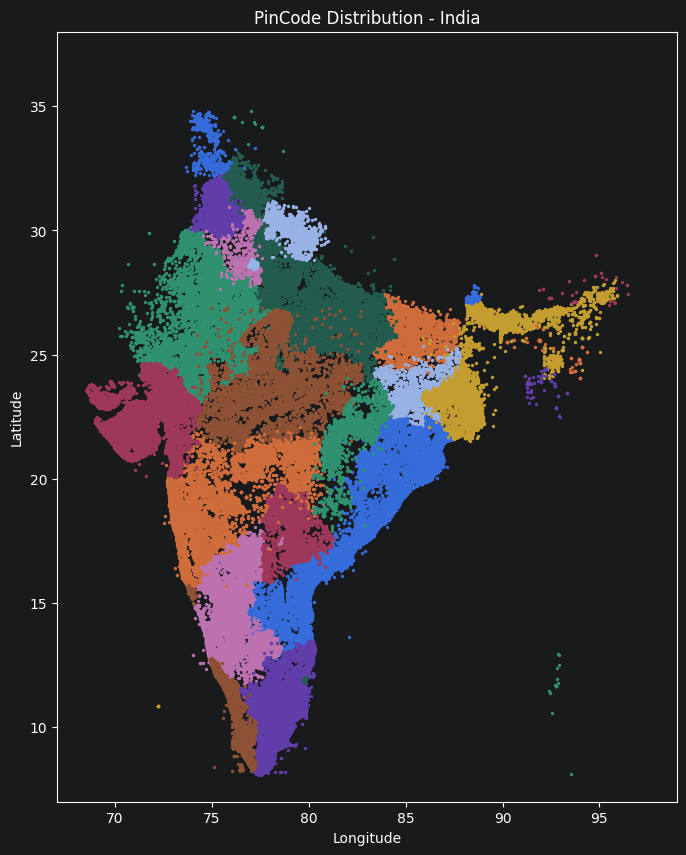

In [174]:
# To Print Full Map of India

plt.figure(figsize=(8, 10))
# limiting to approx Geographical Coords range
plt.ylim(7,38)
plt.xlim(67,99)

# dropping points with null coordinates and duplicates
df = df.dropna(subset=['Latitude', 'Longitude'])
df = df.drop_duplicates(subset=['Pincode', 'Latitude', 'Longitude'])

# changing coordinates from str to numeric for plotting
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

states = df.drop_duplicates("StateName")
states = states["StateName"]
#print(states)
for i in range(len(states)):
    state_name = states.iloc[i]
    state_df = df[df["StateName"] == state_name]

    state_bound = bounds_df[bounds_df["StateName"] == state_name]
    min_lat = state_bound['minLat'].iloc[0]
    max_lat = state_bound['maxLat'].iloc[0]
    min_lon = state_bound['minLong'].iloc[0]
    max_lon = state_bound['maxLong'].iloc[0]

    # cleaning to remove outliers for each state
    state_df = state_df[(state_df['Latitude'] > min_lat) &
                        (state_df['Latitude'] < max_lat)]
    state_df = state_df[(state_df['Longitude'] > min_lon) &
                        (state_df['Longitude'] < max_lon)]

    plt.scatter(state_df['Longitude'], state_df['Latitude'], s=2)

plt.title("PinCode Distribution - India")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## Implementing K-Means Class and Plotting Function

In [175]:
class KMeans:
    def __init__(self, k = 6, max_iters = 200, random_seed = 42):
        self.k = k
        self.max_iters = max_iters
        self.random_seed = random_seed
        self.centroids = None
        self.labels = None

    def fit(self, X):
        np.random.seed(self.random_seed)

        # randomly choosing initial centroids
        idx = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[idx]

        for i in range(self.max_iters):
            # X is (N,2) matrix with each row having coordinates
            # centroids is (k,2)

            # Slow
            # distances = []
            # for point in X:
            #     row = []
            #     for centroid in self.centroids:
            #         d = np.sqrt(np.sum((point - centroid)**2))
            #         row.append(d)
            #     distances.append(row)

            # vectorised(fast)
            # Expanding X to (N, 1, 2) by X[:, np.newaxis, :] or X[:, None]
            # (N, 1, 2) - (k, 2) = (N,1,2) - (1,k,2) = (N,k,2)
            distances = np.linalg.norm(X[:, None] - self.centroids, axis=2) # now (N,k)

            # Take label (index) with minimum distance (across columns) for one point (one row)
            new_labels = np.argmin(distances, axis=1)

            # if no change, break
            if self.labels is not None and np.array_equal(self.labels, new_labels):
                break

            self.labels = new_labels
            # update new centroids
            new_centroids = np.zeros((self.k, X.shape[1]))
            for ki in range(self.k):
                cluster_points = X[self.labels == ki]
                if len(cluster_points) > 0: new_centroids[ki] = cluster_points.mean(axis=0)
                else: new_centroids[ki] = X[np.random.choice(len(X))] # empty cluster => reassign random point
            self.centroids = new_centroids

        return self


In [176]:
def show_state_clusters(state_name, k = 6):
    state_df = df[df["StateName"] == state_name]

    state_bound = bounds_df[bounds_df["StateName"] == state_name]
    min_lat = state_bound['minLat'].iloc[0]
    max_lat = state_bound['maxLat'].iloc[0]
    min_long = state_bound['minLong'].iloc[0]
    max_long = state_bound['maxLong'].iloc[0]

    # cleaning to remove outliers for each state
    state_df = state_df[(state_df['Latitude'] > min_lat) &
                        (state_df['Latitude'] < max_lat)]
    state_df = state_df[(state_df['Longitude'] > min_long) &
                        (state_df['Longitude'] < max_long)]

    # feature matrix (N,2)
    X = state_df[['Longitude', 'Latitude']].values

    kmeans = KMeans(k)
    kmeans.fit(X)

    state_df['Cluster'] = kmeans.labels

    y_scale = (max_lat-min_lat) / (max_long-min_long)
    plt.figure(figsize=(8, 8*y_scale))

    for i in range(kmeans.k):
        cluster_points = state_df[state_df['Cluster'] == i]
        div_counts = cluster_points['DivisionName'].value_counts()
        district_counts = cluster_points['District'].value_counts()

        if len(district_counts) > 0: probable_district = district_counts.idxmax()
        else: probable_district = "None"

        if len(div_counts) > 0: divname = div_counts.idxmax()
        else: divname = "None"

        plt.scatter(cluster_points['Longitude'], cluster_points['Latitude'], label=f'Cluster {i}', s=5, alpha=0.8)
        print(f"Cluster {i}: {cluster_points['Cluster'].count()} Locations, Probable District & Division: {probable_district}, {divname}")

    plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
                color='white', marker='*', s=100, label='Centroids')

    plt.ylim(min_lat - 1, max_lat + 1)
    plt.xlim(min_long - 1, max_long + 1)
    plt.title(f'Geographical Clusters of PinCodes in {state_name}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


## Demonstration : show_state_clusters(StateName, No of Clusters)

Each cluster contains multiple locations, and a probable district and DivisionName has been specified for each cluster

Cluster 0: 1255 Locations, Probable District & Division: BANDA, Banda Division
Cluster 1: 1309 Locations, Probable District & Division: GORAKHPUR, Gorakhpur Division
Cluster 2: 1523 Locations, Probable District & Division: MEERUT, Meerut Division
Cluster 3: 1882 Locations, Probable District & Division: GONDA, Gonda Division
Cluster 4: 1228 Locations, Probable District & Division: KHERI, Kheri Division
Cluster 5: 855 Locations, Probable District & Division: BUDAUN, Bareilly Division
Cluster 6: 1331 Locations, Probable District & Division: AGRA, Aligarh Division
Cluster 7: 1085 Locations, Probable District & Division: JALAUN, Etawah Division
Cluster 8: 459 Locations, Probable District & Division: JHANSI, Mainpuri Division
Cluster 9: 1092 Locations, Probable District & Division: PRAYAGRAJ, Mirzapur Division


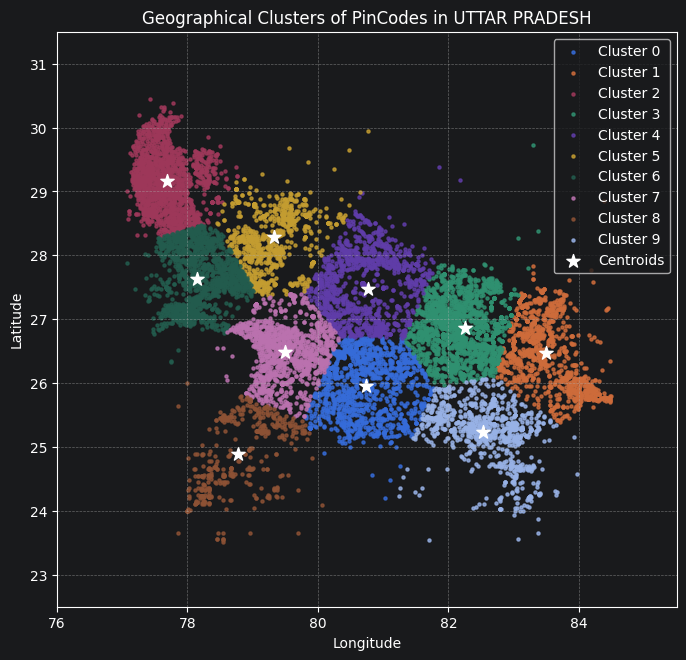

Cluster 0: 476 Locations, Probable District & Division: KHAMMAM, Khammam Division
Cluster 1: 964 Locations, Probable District & Division: KARIMNAGAR, Karimnagar Division
Cluster 2: 732 Locations, Probable District & Division: NIZAMABAD, Nizamabad Division
Cluster 3: 654 Locations, Probable District & Division: NALGONDA, Suryapet Division
Cluster 4: 455 Locations, Probable District & Division: Narayanpet, Mahabubnagar Division
Cluster 5: 478 Locations, Probable District & Division: HYDERABAD, Nalgonda Division


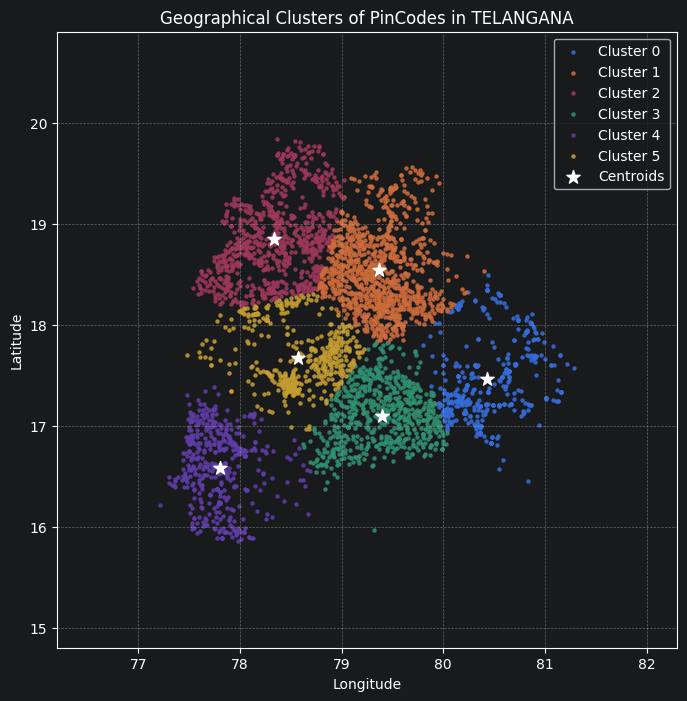

In [180]:
show_state_clusters("UTTAR PRADESH", 10)
show_state_clusters("TELANGANA")